# NexaRetail Sales Performance Analysis
## Exploratory Data Analysis & Business Insights

### Objective:
#### This project analyzes NexaRetail's retail sales data to understand revenue drivers, customer purchasing behaviour, regional product preferences and operational inefficiencies.

#### Business Questions:
##### 1. What Drives Revenue?
##### 2. Which cities perform best?
##### 3. Which products generate the highest sales?
##### 4. Where are returns hurting the business?
##### 5. What actions should management prioritize?

## Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent color palette used across every chart in this notebook
COLOR_REVENUE = "#1f77b4"   # Blue
COLOR_RETURNS = "#d62728"   # Red
COLOR_AOV     = "#2ca02c"   # Green

sns.set_style("whitegrid")
plt.rcParams.update({"axes.titlesize": 13, "axes.labelsize": 11, "font.size": 10})

In [2]:
df = pd.read_csv("P3_Dataset.csv")
df.head()

,order_date,store_name,store_type,city,state,product_name,category,quantity,unit_price,total_amount,channel,return_reason
0,16-01-2023,Sharma Kirana,Kirana,Kolhapur,Maharashtra,NexaGold Wheat Atta 10kg,Atta,36,140,5040,Offline,NaN
1,28-01-2023,Patil General,Kirana,Pune,Maharashtra,NexaGold Toor Dal 1kg,Dal,15,50,750,Online,NaN
2,05-01-2023,Patel Kirana,Kirana,Rajkot,Gujarat,NexaGold Sunflower Oil 5L,Edible Oil,4,140,560,Offline,NaN
3,13-01-2023,Thakur Traders,Kirana,Nagpur,Maharashtra,NexaCrunch Mixture 200g,Snacks,15,50,750,Offline,NaN
4,12-01-2023,Reliance Fresh Baner,Supermarket,Pune,Maharashtra,NexaClean Dishwash 500ml,Household,6,110,660,Offline,Late Delivery


In [3]:
df.shape

(11875, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11875 entries, 0 to 11874
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   order_date     11875 non-null  str  
 1   store_name     11875 non-null  str  
 2   store_type     11875 non-null  str  
 3   city           11875 non-null  str  
 4   state          11875 non-null  str  
 5   product_name   11875 non-null  str  
 6   category       11875 non-null  str  
 7   quantity       11875 non-null  int64
 8   unit_price     11875 non-null  int64
 9   total_amount   11875 non-null  int64
 10  channel        11875 non-null  str  
 11  return_reason  4443 non-null   str  
dtypes: int64(3), str(9)
memory usage: 1.1 MB


In [5]:
df.isnull().sum()

order_date          0
store_name          0
store_type          0
city                0
state               0
product_name        0
category            0
quantity            0
unit_price          0
total_amount        0
channel             0
return_reason    7432
dtype: int64

In [6]:
df.describe(include='all')

,order_date,store_name,store_type,city,state,product_name,category,quantity,unit_price,total_amount,channel,return_reason
count,11875,11875,11875,11875,11875,11875,11875,11875.000000,11875.000000,11875.000000,11875,4443
unique,336,40,2,10,2,21,8,NaN,NaN,NaN,2,3
top,01-10-2023,Big Bazaar Vadodara,Kirana,Kolhapur,Maharashtra,NexaCrunch Mixture 200g,Dal,NaN,NaN,NaN,Offline,Late Delivery
freq,61,327,8912,1254,7179,610,1736,NaN,NaN,NaN,8313,1507
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.436379,195.316211,4012.964211,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.540252,169.452667,4596.895645,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,30.000000,30.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,50.000000,900.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000,110.000000,2100.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.000000,280.000000,5320.000000,NaN,NaN


## Dataset Overview:
#### Rows: 11875
#### Columns: 12
#### Time Period: Jan-Dec 2023
#### Cities: 10 (Across MH and GJ)
#### Categories: 8
#### Products: 21
#### Store Types: 2 (Kirana/SuperMarket)
#### Channels: 2 (Offline/Online)

**Findings**
- No nulls in any transactional field (`order_date`, `city`, `product_name`, `quantity`, `unit_price`, `total_amount`, etc.).
- `return_reason` is null for every non-returned order by design — it is only populated when `returned` is True, so this is expected, not missing data.
- `quantity` and `unit_price` both show a tight, sensible spread with no negative or zero values, so the data does not need outlier correction before analysis.

## Data Preparation

**Objective**
Prepare the raw transaction data for time-based and return-based analysis.

**Business Importance**
Revenue trends and return patterns cannot be analyzed without a clean date field and a clear return flag — this step underpins every downstream section.

**Methodology**
Parse `order_date` into a proper datetime type, extract the `month`, `week` and `day_of_week`, and derive a boolean `returned` flag from `return_reason`.

In [7]:
df['order_date'] = pd.to_datetime(df['order_date'], format="%d-%m-%Y")
df['month'] = df['order_date'].dt.month
df['week'] = df['order_date'].dt.isocalendar().week
df['day_of_week'] = df['order_date'].dt.day_name()
df['returned'] = df['return_reason'].notnull()

df[['order_date', 'month', 'week', 'day_of_week', 'return_reason', 'returned']].head()

,order_date,month,week,day_of_week,return_reason,returned
0,2023-01-16,1,3,Monday,NaN,False
1,2023-01-28,1,4,Saturday,NaN,False
2,2023-01-05,1,1,Thursday,NaN,False
3,2023-01-13,1,2,Friday,NaN,False
4,2023-01-12,1,2,Thursday,Late Delivery,True


**Interpretation**
The dataset is now ready for monthly and weekly seasonality analysis (via `month`, `week`, `day_of_week`) and for operational/return analysis (via `returned`).

## KPI Summary

**Objective**
Establish the top-line business metrics that frame the rest of the analysis.

**Business Importance**
A single, at-a-glance scorecard lets management gauge overall business health before drilling into individual dimensions.

**Methodology**
Aggregate revenue, orders, stores, average order value, quantity sold and returns across the full dataset.

In [8]:
total_revenue = df['total_amount'].sum()
total_orders = df['order_date'].count()
total_stores = df['store_name'].nunique()
avg_order_value = df['total_amount'].mean()
total_quantity_sold = df['quantity'].sum()
total_returned_orders = df['returned'].sum()
return_rate_pct = (total_returned_orders / total_orders) * 100

kpi_summary = pd.DataFrame({
    'Metric': ['Total Revenue (Rs.)', 'Total Orders', 'Total Stores', 'Avg Order Value (Rs.)',
               'Total Quantity Sold', 'Returned Orders', 'Return Rate (%)'],
    'Value': [f"{total_revenue:,.0f}", f"{total_orders:,}", total_stores,
              f"{avg_order_value:,.2f}", f"{total_quantity_sold:,}",
              f"{total_returned_orders:,}", f"{return_rate_pct:.2f}"]
})
kpi_summary

,Metric,Value
0,Total Revenue (Rs.),"47,653,950"
1,Total Orders,"11,875"
2,Total Stores,40
3,Avg Order Value (Rs.),"4,012.96"
4,Total Quantity Sold,"242,682"
5,Returned Orders,"4,443"
6,Return Rate (%),37.41


**Findings**
- Total revenue: Rs. 4,76,53,950 across 11,875 orders from 40 stores.
- Average order value: ~Rs. 4,013 — a steady figure for a Kirana/Supermarket mix.
- 2,42,682 units sold in total.
- 4,443 orders (37.4%) were returned.

**Interpretation**
The business runs on high order volume rather than high-ticket transactions, and a return rate above 37% is materially high for retail and warrants a dedicated operational deep-dive (see Operational Analysis).

**Recommendation**
Treat the ~37% return rate as a top management priority; investigate root causes before scaling revenue further.

## Revenue Analysis

### Revenue Drivers

**Objective**
Understand which dimensions — time, geography, category and channel — contribute most to overall business revenue.

**Business Importance**
Identifying major revenue drivers enables better inventory allocation, marketing investment and regional planning.

**Methodology**
Revenue aggregated across month, geography (city and store type), category and sales channel using pandas groupby operations.

#### Revenue by Month

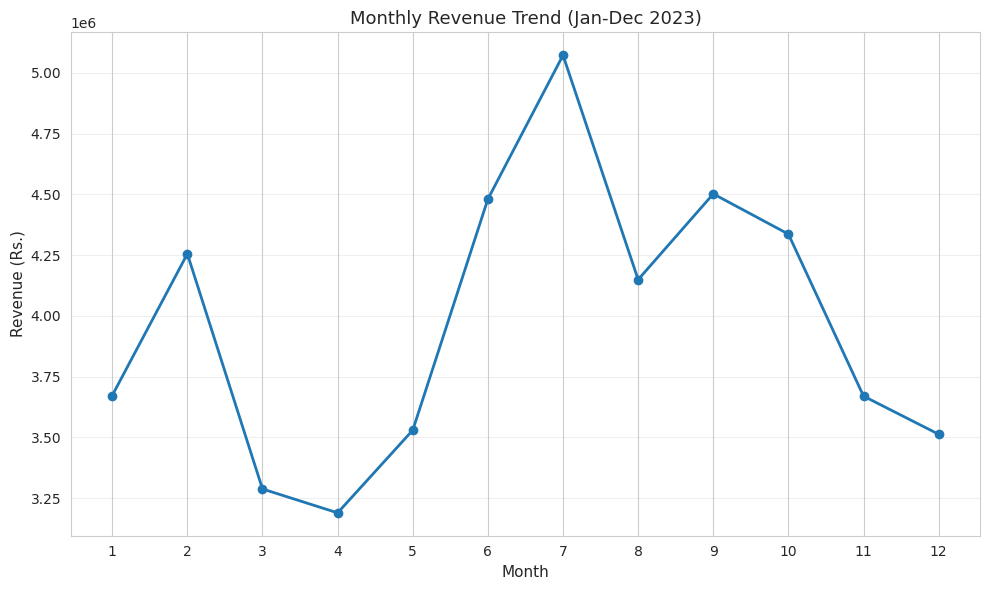

In [9]:
monthly_revenue_summary = df.groupby('month')['total_amount'].sum()

plt.figure(figsize=(10, 6))
monthly_revenue_summary.plot(kind='line', marker='o', color=COLOR_REVENUE, linewidth=2)
plt.title('Monthly Revenue Trend (Jan-Dec 2023)')
plt.xlabel('Month')
plt.ylabel('Revenue (Rs.)')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Weekly Seasonality (Day-of-Week Pattern)

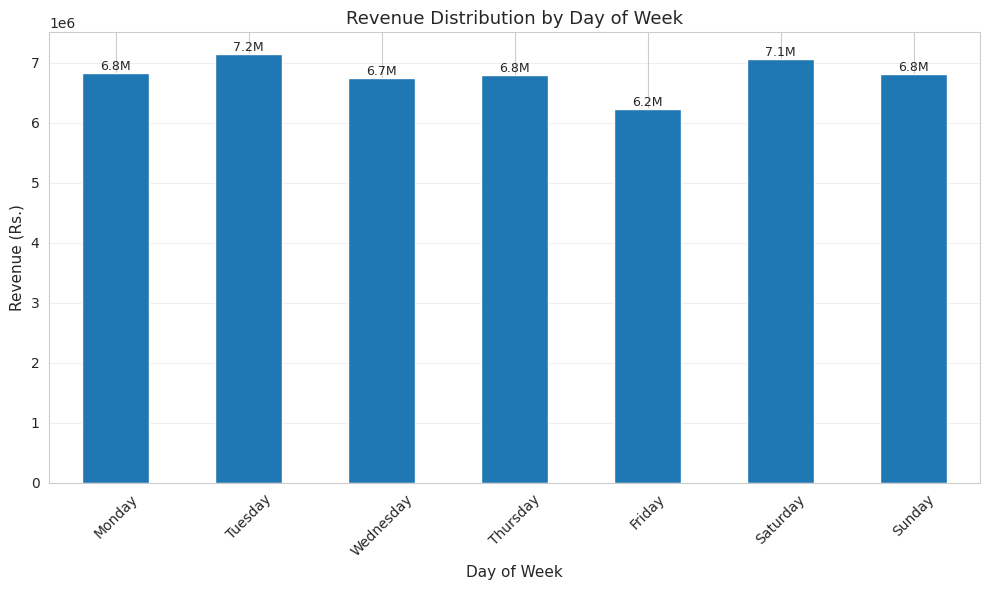

In [10]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_revenue_summary = (
    df.groupby('day_of_week')['total_amount'].sum().reindex(day_order)
)

plt.figure(figsize=(10, 6))
ax = weekday_revenue_summary.plot(kind='bar', color=COLOR_REVENUE)
plt.title('Revenue Distribution by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue (Rs.)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(weekday_revenue_summary):
    ax.text(i, v, f"{v/1e6:.1f}M", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

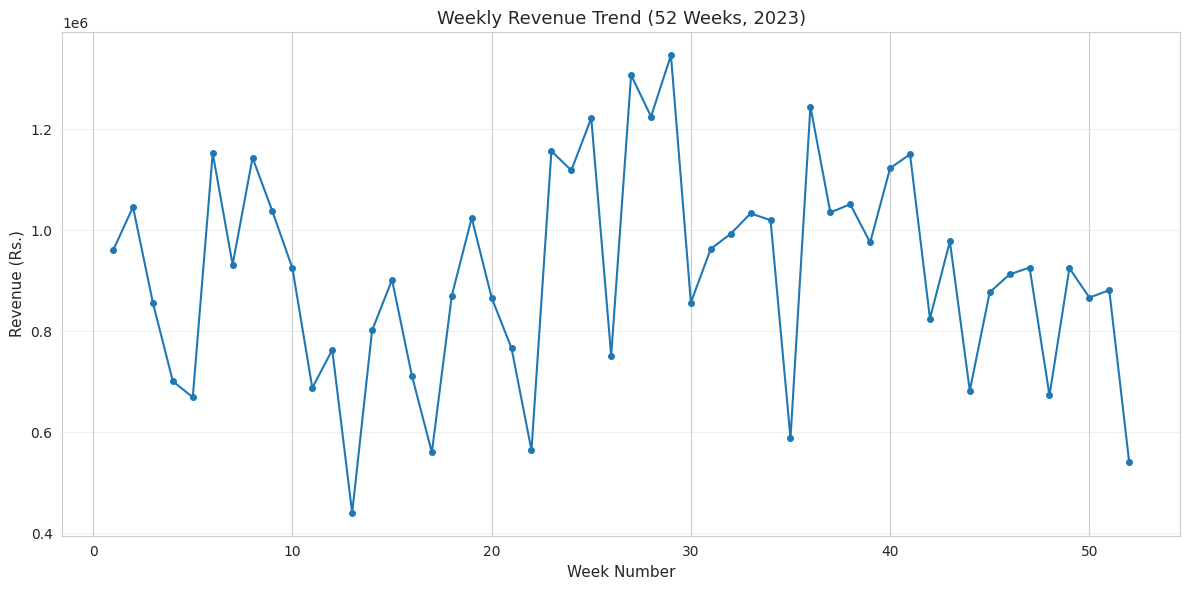

In [11]:
weekly_revenue_summary = df.groupby('week')['total_amount'].sum()

plt.figure(figsize=(12, 6))
weekly_revenue_summary.plot(kind='line', marker='o', markersize=4, color=COLOR_REVENUE, linewidth=1.5)
plt.title('Weekly Revenue Trend (52 Weeks, 2023)')
plt.xlabel('Week Number')
plt.ylabel('Revenue (Rs.)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Revenue by Geography (City & Store Type)

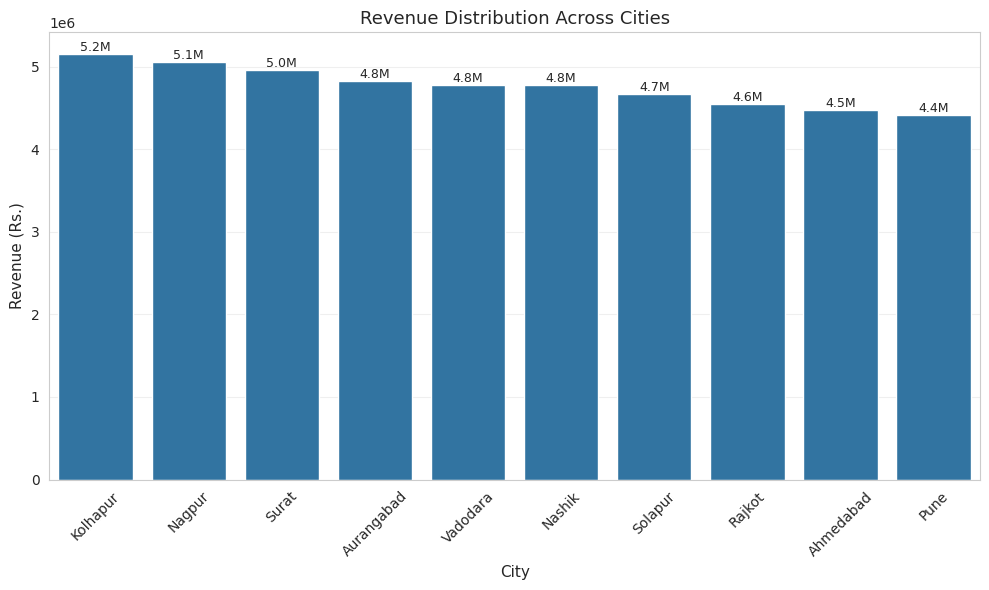

In [12]:
city_revenue_summary = (
    df.groupby('city')['total_amount'].sum()
    .sort_values(ascending=False).reset_index()
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=city_revenue_summary, x='city', y='total_amount', color=COLOR_REVENUE)
plt.title('Revenue Distribution Across Cities')
plt.xlabel('City')
plt.ylabel('Revenue (Rs.)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(city_revenue_summary['total_amount']):
    ax.text(i, v, f"{v/1e6:.1f}M", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

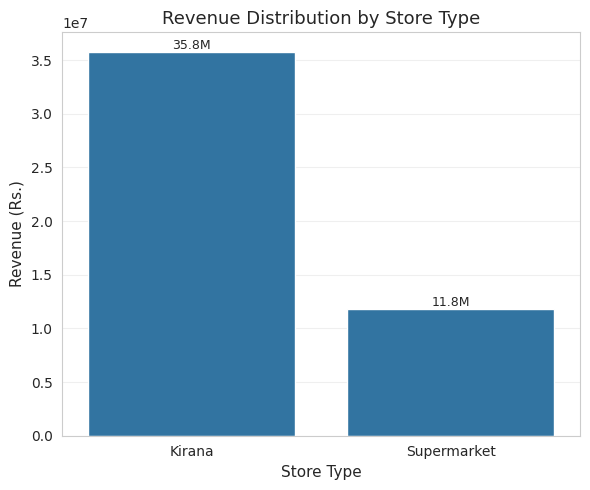

In [13]:
store_type_revenue_summary = (
    df.groupby('store_type')['total_amount'].sum()
    .sort_values(ascending=False).reset_index()
)

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=store_type_revenue_summary, x='store_type', y='total_amount', color=COLOR_REVENUE)
plt.title('Revenue Distribution by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Revenue (Rs.)')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(store_type_revenue_summary['total_amount']):
    ax.text(i, v, f"{v/1e6:.1f}M", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

#### Revenue by Category

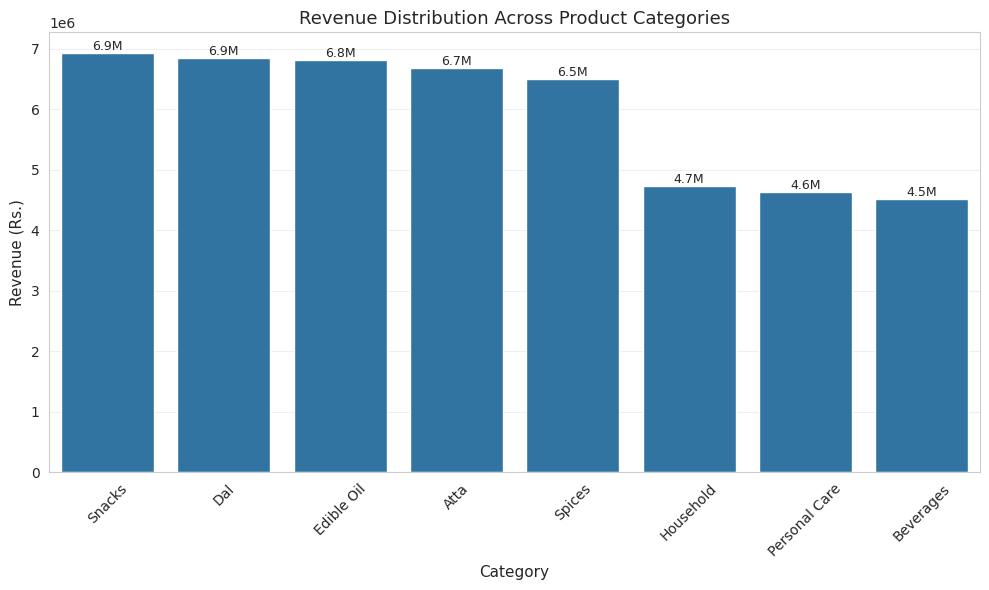

In [14]:
category_revenue_summary = (
    df.groupby('category')['total_amount'].sum()
    .sort_values(ascending=False).reset_index()
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=category_revenue_summary, x='category', y='total_amount', color=COLOR_REVENUE)
plt.title('Revenue Distribution Across Product Categories')
plt.xlabel('Category')
plt.ylabel('Revenue (Rs.)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(category_revenue_summary['total_amount']):
    ax.text(i, v, f"{v/1e6:.1f}M", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

#### Revenue by Channel

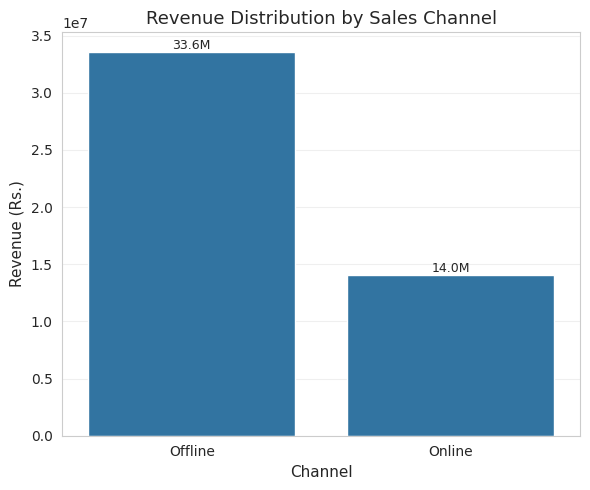

In [15]:
channel_revenue_summary = (
    df.groupby('channel')['total_amount'].sum()
    .sort_values(ascending=False).reset_index()
)

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=channel_revenue_summary, x='channel', y='total_amount', color=COLOR_REVENUE)
plt.title('Revenue Distribution by Sales Channel')
plt.xlabel('Channel')
plt.ylabel('Revenue (Rs.)')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(channel_revenue_summary['total_amount']):
    ax.text(i, v, f"{v/1e6:.1f}M", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

**Findings**
- Revenue ranges from Rs. 44.1L (Pune) to Rs. 51.6L (Kolhapur) across cities — only a ~14% spread, i.e. fairly balanced geographically.
- Kirana stores generate Rs. 3.58Cr (75%) of revenue vs Rs. 1.18Cr (25%) from Supermarkets.
- Category revenue is spread narrowly between 9.5% and 14.4% each — no single category dominates.
- Offline is the primary channel at Rs. 3.36Cr (70.5%) vs Online at Rs. 1.40Cr (29.5%).
- Revenue peaked in July (Rs. 50.7L) and dipped in April (Rs. 31.9L).

**Interpretation**
Revenue is diversified across categories and cities, which reduces concentration risk, but the business remains heavily dependent on the Kirana/Offline model.

**Recommendation**
Use the Kirana/Offline base as the stable core while piloting targeted growth investments in Online and Supermarket channels.

### Geographic Analysis

**Objective**
Identify top-performing cities and understand whether their revenue is driven by order volume or order value.

**Business Importance**
Distinguishing volume-driven growth from value-driven growth changes the marketing and operational levers management should pull.

**Methodology**
Rank cities by revenue, then compare order counts against average order value (AOV) for each city.

#### Top Revenue Cities

In [16]:
top_revenue_cities = city_revenue_summary.head(3)
top_revenue_cities

,city,total_amount
0,Kolhapur,5157800
1,Nagpur,5055540
2,Surat,4958680


#### Orders vs Average Order Value

In [17]:
city_orders_aov_summary = (
    df.groupby('city')
    .agg(total_revenue=('total_amount', 'sum'), total_orders=('order_date', 'count'))
    .sort_values('total_revenue')
)
city_orders_aov_summary['avg_order_value'] = (
    city_orders_aov_summary['total_revenue'] / city_orders_aov_summary['total_orders']
)
city_orders_aov_summary

,total_revenue,total_orders,avg_order_value
city,,,
Pune,4410500,1102,4002.268603
Ahmedabad,4472620,1143,3913.053368
Rajkot,4552270,1163,3914.247635
Solapur,4663150,1200,3885.958333
Nashik,4773550,1183,4035.122570
Vadodara,4778070,1220,3916.450820
Aurangabad,4831770,1230,3928.268293
Surat,4958680,1170,4238.188034
Nagpur,5055540,1210,4178.132231


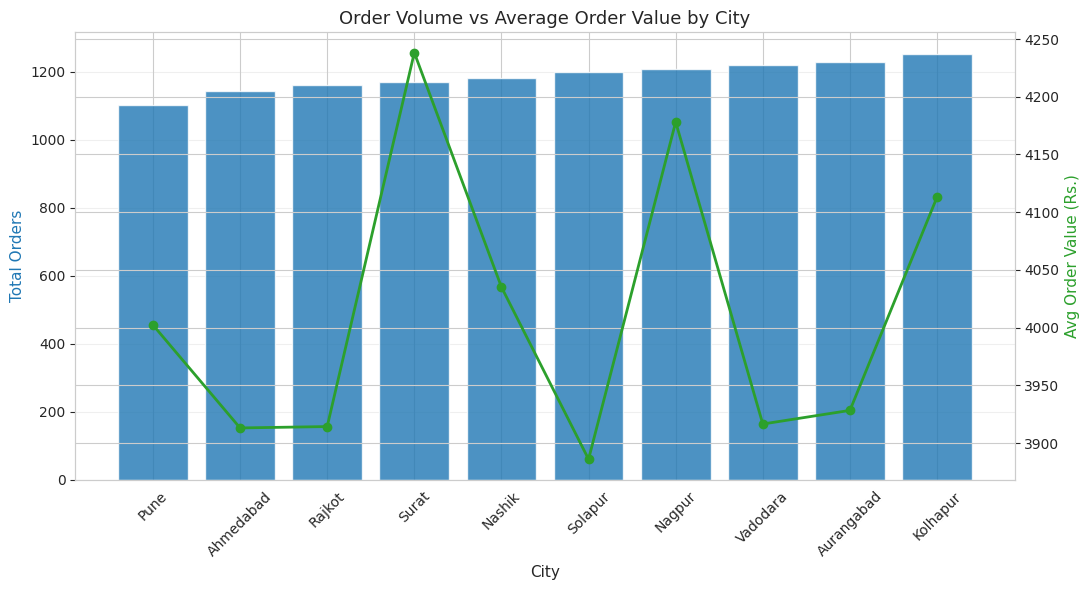

In [18]:
fig, ax1 = plt.subplots(figsize=(11, 6))
cities_sorted = city_orders_aov_summary.sort_values('total_orders').index

ax1.bar(cities_sorted, city_orders_aov_summary.loc[cities_sorted, 'total_orders'],
        color=COLOR_REVENUE, alpha=0.8, label='Total Orders')
ax1.set_ylabel('Total Orders', color=COLOR_REVENUE)
ax1.set_xlabel('City')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(cities_sorted, city_orders_aov_summary.loc[cities_sorted, 'avg_order_value'],
         color=COLOR_AOV, marker='o', linewidth=2, label='Avg Order Value')
ax2.set_ylabel('Avg Order Value (Rs.)', color=COLOR_AOV)

plt.title('Order Volume vs Average Order Value by City')
fig.tight_layout()
plt.show()

#### Top Products (Geographic Context)

In [19]:
top_products_by_revenue = (
    df.groupby('product_name')['total_amount'].sum()
    .sort_values(ascending=False).head(5).reset_index()
)
top_products_by_revenue['revenue_share_pct'] = (
    top_products_by_revenue['total_amount'] / total_revenue * 100
)
top_products_by_revenue

,product_name,total_amount,revenue_share_pct
0,NexaCrunch Mixture 200g,2534990,5.319580
1,NexaGold Sunflower Oil 5L,2439230,5.118631
2,NexaClean Dishwash 500ml,2433190,5.105957
3,NexaGold Toor Dal 1kg,2361080,4.954636
4,NexaGold Wheat Atta 5kg,2359630,4.951594


#### Top Categories

In [20]:
top_categories = category_revenue_summary.head(3)
top_categories

,category,total_amount
0,Snacks,6926430
1,Dal,6851770
2,Edible Oil,6811800


**Findings**
- Order counts vary far more across cities than average order value does — AOV stays in a tight Rs. 3,885-Rs. 4,035 band.
- Kolhapur, Nagpur and Surat lead on revenue primarily because they generate more orders, not larger ones.
- The top 5 products together contribute a meaningful share of total revenue, led by NexaCrunch Mixture 200g (~5.3%).

**Interpretation**
Revenue leadership is a function of transaction frequency, not basket size — a critical distinction for growth strategy.

**Recommendation**
Prioritize initiatives that increase purchase frequency (loyalty programs, replenishment reminders) over initiatives aimed purely at increasing basket size.

## Product Analysis

**Objective**
Understand which products drive revenue, how concentrated that contribution is, and how preferences vary by city.

**Business Importance**
Product-level visibility supports SKU-level inventory planning and highlights where localized assortment strategies could help.

**Methodology**
Aggregate revenue by product, compute percentage contribution to total revenue, and identify the top product in each city.

#### Top Products

In [21]:
product_revenue_contribution = (
    df.groupby('product_name')['total_amount'].sum()
    .sort_values(ascending=False).reset_index()
)
product_revenue_contribution['contribution_pct'] = (
    product_revenue_contribution['total_amount'] / total_revenue * 100
)
product_revenue_contribution.head(10)

,product_name,total_amount,contribution_pct
0,NexaCrunch Mixture 200g,2534990,5.319580
1,NexaGold Sunflower Oil 5L,2439230,5.118631
2,NexaClean Dishwash 500ml,2433190,5.105957
3,NexaGold Toor Dal 1kg,2361080,4.954636
4,NexaGold Wheat Atta 5kg,2359630,4.951594
5,NexaCare Soap 100g,2350950,4.933379
6,NexaGold Chana Dal 1kg,2342140,4.914892
7,NexaCrunch Namkeen 150g,2333940,4.897684
8,NexaClean Floor Cleaner 1L,2305780,4.838592
9,NexaCare Shampoo 200ml,2281830,4.788333


#### Contribution

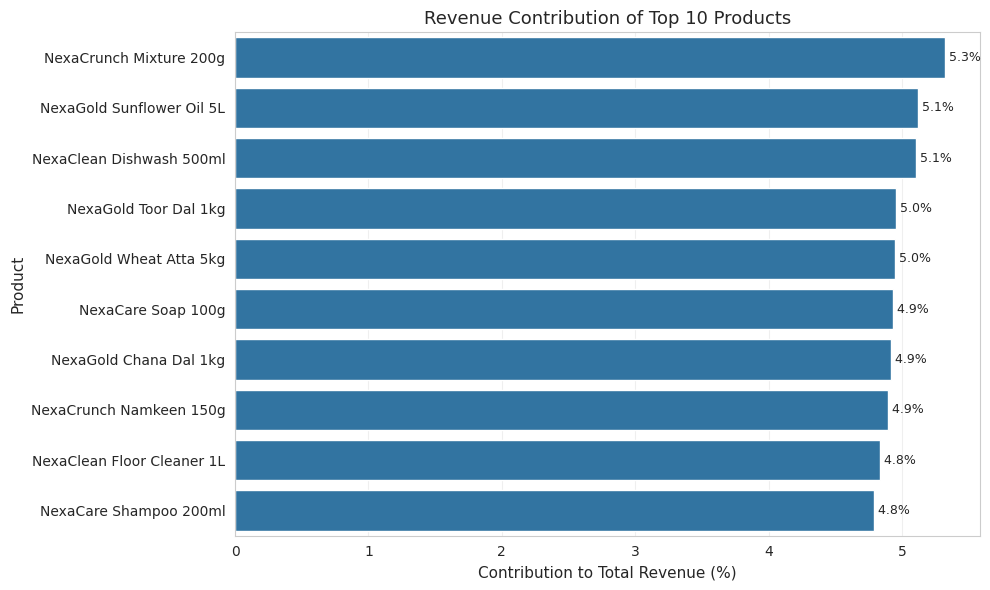

In [22]:
top10_products = product_revenue_contribution.head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top10_products, x='contribution_pct', y='product_name', color=COLOR_REVENUE)
plt.title('Revenue Contribution of Top 10 Products')
plt.xlabel('Contribution to Total Revenue (%)')
plt.ylabel('Product')
plt.grid(axis='x', alpha=0.3)
for i, v in enumerate(top10_products['contribution_pct']):
    ax.text(v, i, f" {v:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()

#### Product by City

In [23]:
product_city_revenue = (
    df.groupby(['city', 'product_name'])['total_amount'].sum().reset_index()
)
top_product_by_city = (
    product_city_revenue.loc[product_city_revenue.groupby('city')['total_amount'].idxmax()]
    .sort_values('total_amount', ascending=False)
    .reset_index(drop=True)
)
top_product_by_city

,city,product_name,total_amount
0,Rajkot,NexaGold Wheat Atta 5kg,419670
1,Nagpur,NexaCrunch Namkeen 150g,342650
2,Kolhapur,NexaGold Sunflower Oil 5L,338060
3,Vadodara,NexaCrunch Namkeen 150g,322880
4,Nashik,NexaCare Shampoo 200ml,304270
5,Pune,NexaGold Toor Dal 1kg,300740
6,Aurangabad,NexaGold Turmeric 200g,295140
7,Ahmedabad,NexaCare Soap 100g,293490
8,Surat,NexaGold Turmeric 200g,292510
9,Solapur,NexaGold Red Chilli 200g,277490


#### Business Opportunity Matrix

This matrix combines each category's revenue share with its return rate to flag where the business earns the most **and** where it is most exposed operationally.

In [24]:
category_opportunity_matrix = (
    df.groupby('category')
    .agg(revenue=('total_amount', 'sum'), total_orders=('order_date', 'count'),
         returned_orders=('returned', 'sum'))
)
category_opportunity_matrix['revenue_share_pct'] = (
    category_opportunity_matrix['revenue'] / total_revenue * 100
)
category_opportunity_matrix['return_rate_pct'] = (
    category_opportunity_matrix['returned_orders'] / category_opportunity_matrix['total_orders'] * 100
)
category_opportunity_matrix.sort_values('revenue_share_pct', ascending=False)

,revenue,total_orders,returned_orders,revenue_share_pct,return_rate_pct
category,,,,,
Snacks,6926430,1707,639,14.534850,37.434095
Dal,6851770,1736,654,14.378179,37.672811
Edible Oil,6811800,1673,617,14.294303,36.879857
Atta,6678890,1685,655,14.015396,38.872404
Spices,6497960,1655,618,13.635722,37.341390
Household,4738970,1184,428,9.944548,36.148649
Personal Care,4632780,1129,433,9.721712,38.352524
Beverages,4515350,1106,399,9.475290,36.075949


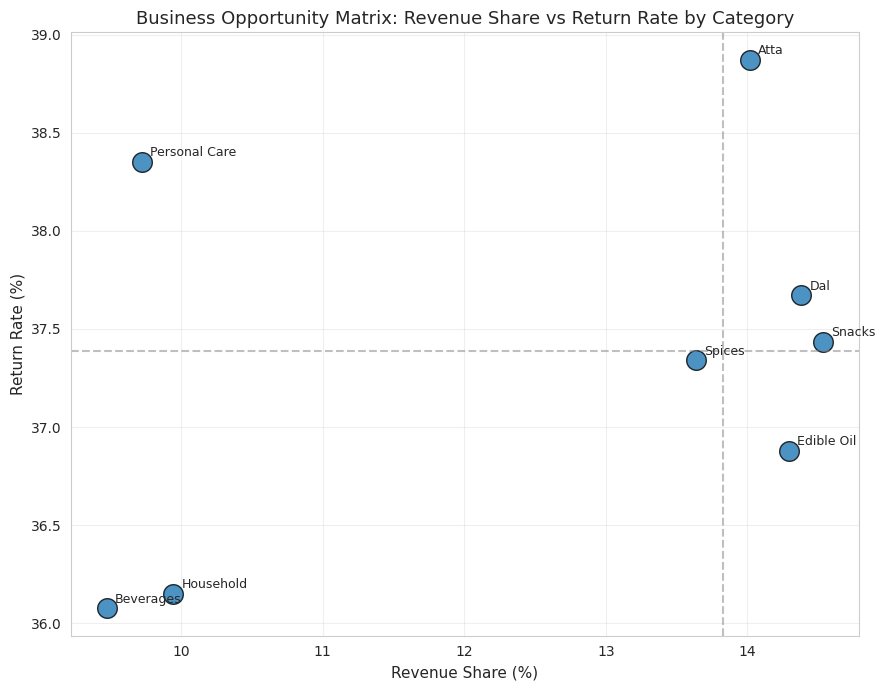

In [25]:
plt.figure(figsize=(9, 7))
plt.scatter(category_opportunity_matrix['revenue_share_pct'],
            category_opportunity_matrix['return_rate_pct'],
            s=200, color=COLOR_REVENUE, edgecolor='black', alpha=0.8)

for cat, row in category_opportunity_matrix.iterrows():
    plt.annotate(cat, (row['revenue_share_pct'], row['return_rate_pct']),
                 textcoords="offset points", xytext=(6, 4), fontsize=9)

plt.axvline(category_opportunity_matrix['revenue_share_pct'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(category_opportunity_matrix['return_rate_pct'].median(), color='gray', linestyle='--', alpha=0.5)
plt.title('Business Opportunity Matrix: Revenue Share vs Return Rate by Category')
plt.xlabel('Revenue Share (%)')
plt.ylabel('Return Rate (%)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Findings**
- Snacks (14.5%), Dal (14.4%) and Edible Oil (14.3%) are the top revenue categories.
- Atta (38.9%) and Personal Care (38.4%) carry the highest return rates among all categories.
- Product preferences differ meaningfully by city — no single product dominates in every city.

**Interpretation**
The highest-revenue categories are not the highest-risk ones, but several mid-revenue categories (Atta, Personal Care) combine solid revenue with elevated return rates — exactly where operational fixes would have the most financial impact.

**Recommendation**
Prioritize return-reduction efforts on Atta and Personal Care before any other category, since they offer the best return-on-effort for return-rate improvement.

**This section combines sales and operational performance to identify products that simultaneously drive revenue and create business risk.**

### Revenue-Risk Analysis by City
Top Product → Revenue Share → Return Rate → Business Recommendation

In [26]:
city_product_performance = (
    df.groupby(['city', 'product_name'])
    .agg(revenue=('total_amount', 'sum'), total_orders=('order_date', 'count'),
         returned_orders=('returned', 'sum'))
    .reset_index()
)

city_top_product_summary = (
    city_product_performance.loc[city_product_performance.groupby('city')['revenue'].idxmax()]
    .reset_index(drop=True)
)

city_revenue_lookup = city_revenue_summary.set_index('city')['total_amount']
city_top_product_summary['return_rate_pct'] = (
    city_top_product_summary['returned_orders'] / city_top_product_summary['total_orders'] * 100
)
city_top_product_summary['revenue_share_within_city_pct'] = (
    city_top_product_summary['revenue'] / city_top_product_summary['city'].map(city_revenue_lookup) * 100
)
city_top_product_summary.sort_values('return_rate_pct', ascending=False)

,city,product_name,revenue,total_orders,returned_orders,return_rate_pct,revenue_share_within_city_pct
8,Surat,NexaGold Turmeric 200g,292510,65,31,47.692308,5.898949
7,Solapur,NexaGold Red Chilli 200g,277490,76,34,44.736842,5.950699
4,Nashik,NexaCare Shampoo 200ml,304270,62,27,43.548387,6.374082
6,Rajkot,NexaGold Wheat Atta 5kg,419670,77,31,40.259740,9.218917
5,Pune,NexaGold Toor Dal 1kg,300740,62,23,37.096774,6.818728
9,Vadodara,NexaCrunch Namkeen 150g,322880,75,27,36.000000,6.757540
2,Kolhapur,NexaGold Sunflower Oil 5L,338060,67,24,35.820896,6.554345
3,Nagpur,NexaCrunch Namkeen 150g,342650,65,23,35.384615,6.777713
1,Aurangabad,NexaGold Turmeric 200g,295140,65,22,33.846154,6.108321
0,Ahmedabad,NexaCare Soap 100g,293490,63,20,31.746032,6.561926


**Findings**
- Rajkot's top revenue product, NexaGold Wheat Atta 5kg, contributes 9.2% of the city's revenue while carrying a 40.3% return rate — the single sharpest revenue-vs-risk mismatch in the dataset.
- Several other cities show their top revenue product also sitting at an elevated return rate, though less extreme than Rajkot.
- This pattern is not limited to one city — it recurs across multiple top city-product pairs, indicating a systemic rather than isolated issue.

**Interpretation**
When a city's single largest revenue product also has a disproportionately high return rate, that product becomes a concentrated point of business risk — a quality or fulfillment issue there has an outsized impact on that city's bottom line.

**Recommendation**
Launch a targeted quality/delivery audit for each city's top revenue product, starting with Rajkot's NexaGold Wheat Atta 5kg.

## Operational Analysis

**Objective**
Quantify returns and identify where they are concentrated by reason, category, city and product.

**Business Importance**
Returns directly erode margin and signal quality, delivery or fulfillment issues that can be fixed operationally.

**Methodology**
Compute return rate and return reason distribution, then break both down by category, city and product.

#### Returns

In [27]:
print(f"Total Returned Orders: {total_returned_orders:,}")
print(f"Return Rate: {return_rate_pct:.2f}%")

Total Returned Orders: 4,443
Return Rate: 37.41%


#### Return Reasons

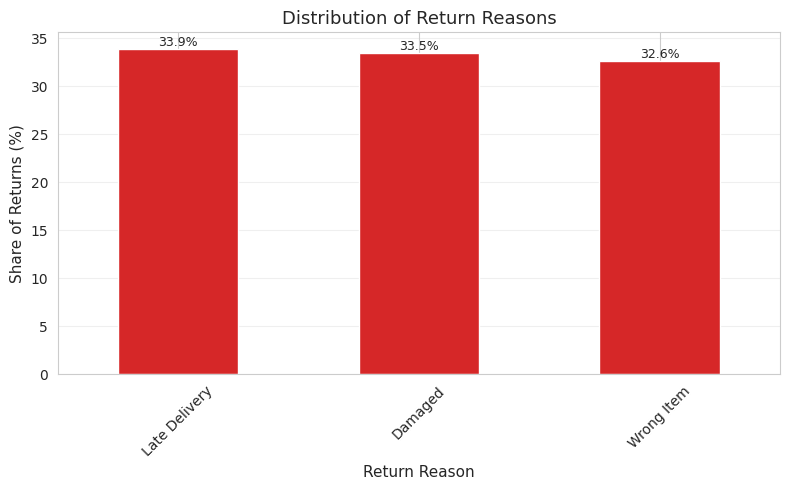

In [28]:
return_reason_summary = (
    df['return_reason'].value_counts(normalize=True).mul(100).round(2)
)

plt.figure(figsize=(8, 5))
ax = return_reason_summary.plot(kind='bar', color=COLOR_RETURNS)
plt.title('Distribution of Return Reasons')
plt.xlabel('Return Reason')
plt.ylabel('Share of Returns (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(return_reason_summary):
    ax.text(i, v, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

#### Return Rate by Category

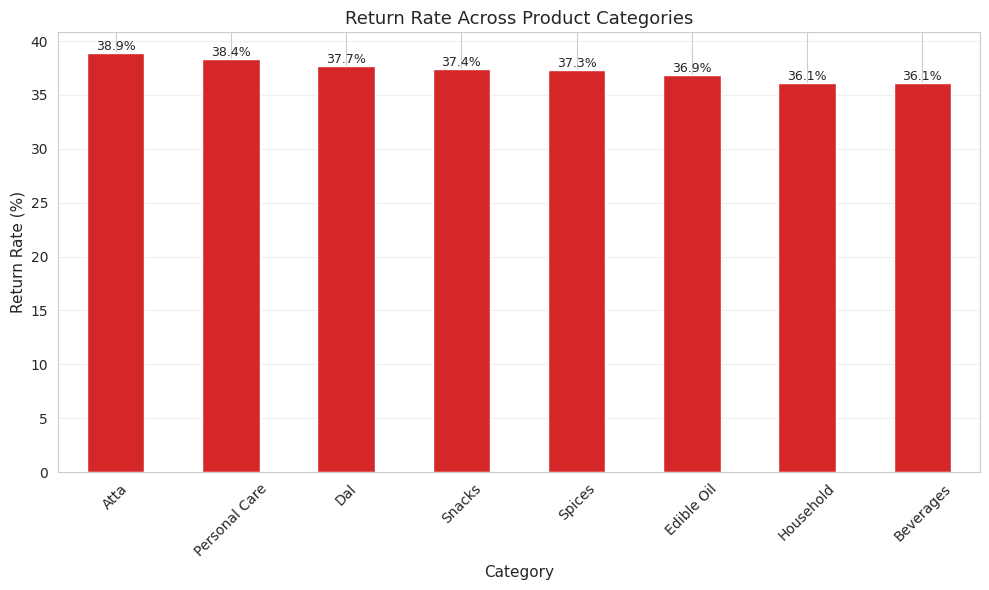

In [29]:
category_return_rate_summary = (
    df.groupby('category')['returned'].mean().mul(100).sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
ax = category_return_rate_summary.plot(kind='bar', color=COLOR_RETURNS)
plt.title('Return Rate Across Product Categories')
plt.xlabel('Category')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(category_return_rate_summary):
    ax.text(i, v, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

#### Return Rate by City

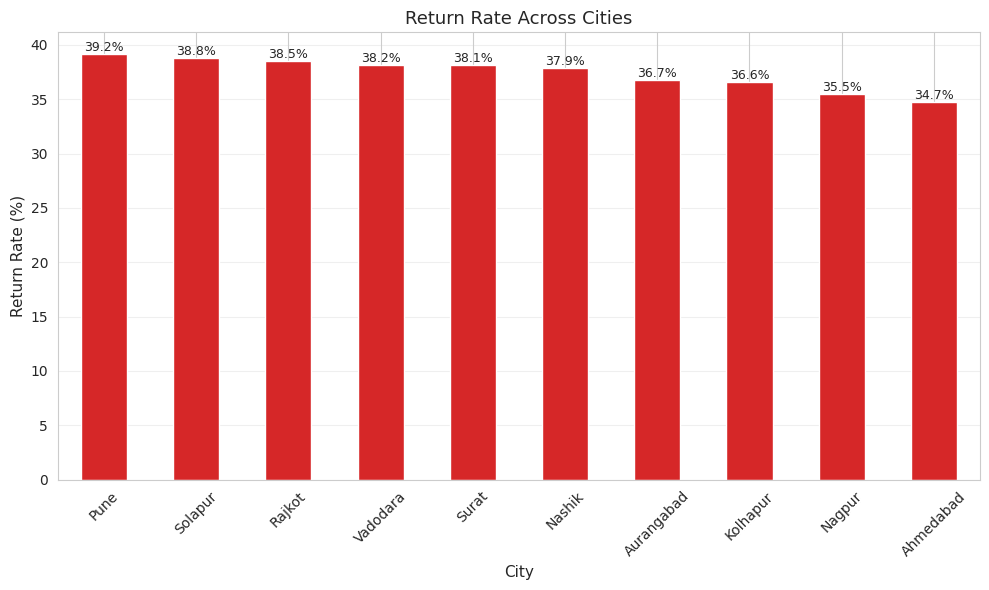

In [30]:
city_return_rate_summary = (
    df.groupby('city')['returned'].mean().mul(100).sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
ax = city_return_rate_summary.plot(kind='bar', color=COLOR_RETURNS)
plt.title('Return Rate Across Cities')
plt.xlabel('City')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(city_return_rate_summary):
    ax.text(i, v, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

#### Top Returning Categories

In [31]:
top_returning_categories = category_return_rate_summary.head(3)
top_returning_categories

category
Atta             38.872404
Personal Care    38.352524
Dal              37.672811
Name: returned, dtype: float64

#### Top Returning Products

In [32]:
product_return_rate_summary = (
    df.groupby('product_name')
    .agg(total_orders=('order_date', 'count'), returned_orders=('returned', 'sum'))
)
product_return_rate_summary['return_rate_pct'] = (
    product_return_rate_summary['returned_orders'] / product_return_rate_summary['total_orders'] * 100
)
top_returning_products = product_return_rate_summary.sort_values('return_rate_pct', ascending=False).head(10)
top_returning_products

,total_orders,returned_orders,return_rate_pct
product_name,,,
NexaGold Multigrain Atta 5kg,540,224,41.481481
NexaGold Moong Dal 1kg,552,221,40.036232
NexaGold Garam Masala 100g,561,222,39.572193
NexaCare Shampoo 200ml,559,220,39.355993
NexaGold Wheat Atta 5kg,580,223,38.448276
NexaFresh Mango Juice 1L,559,214,38.282648
NexaCrunch Chips 100g,536,204,38.059701
NexaGold Red Chilli 200g,538,204,37.918216
NexaGold Sunflower Oil 1L,555,210,37.837838


**Findings**
- Returns are split almost evenly across 3 reasons: Late Delivery (33.9%), Damaged (33.4%) and Wrong Item (32.6%).
- Atta (38.9%) and Personal Care (38.4%) are the highest-returning categories; Beverages (36.1%) is the lowest.
- Pune (39.2%), Solapur (38.8%) and Rajkot (38.5%) are the highest-returning cities; Ahmedabad (34.7%) is the lowest.
- The top-returning products track closely with the top-returning categories, rather than being isolated to a handful of unrelated SKUs.

**Interpretation**
No single reason, category or city explains the bulk of returns — the ~37% return rate is a distributed, systemic issue spanning delivery, quality and fulfillment, not a one-off problem.

**Recommendation**
Address returns via three parallel workstreams — logistics (late delivery), packaging/quality (damaged), and order-fulfillment accuracy (wrong item) — rather than a single fix.

## Correlation Analysis: Basket Size, Channel & Store Type

**Objective**
Test whether basket size (quantity per order) is meaningfully related to sales channel or store type.

**Business Importance**
If Online orders or Supermarket orders carry systematically larger baskets, that changes how NexaRetail should prioritize channel and format investment.

**Methodology**
Compare average basket size (`quantity`) across channel and store type, then build a correlation matrix across `quantity`, `unit_price`, `total_amount` and one-hot encoded `channel`/`store_type`.

#### Average Basket Size by Channel & Store Type

In [33]:
basket_size_summary = (
    df.groupby(['channel', 'store_type'])['quantity'].mean().reset_index()
    .rename(columns={'quantity': 'avg_basket_size'})
)
basket_size_summary

,channel,store_type,avg_basket_size
0,Offline,Kirana,20.381052
1,Offline,Supermarket,20.491084
2,Online,Kirana,20.339192
3,Online,Supermarket,20.989865


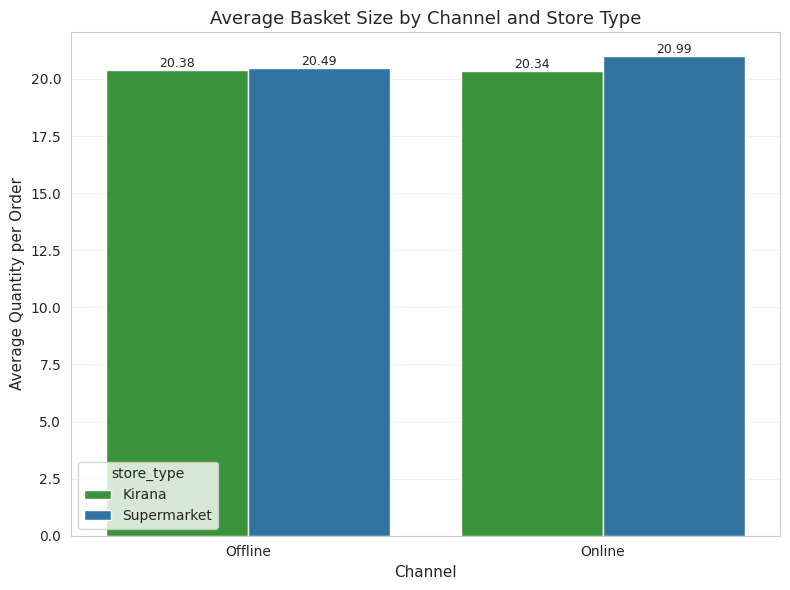

In [34]:
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=basket_size_summary, x='channel', y='avg_basket_size', hue='store_type',
                  palette=[COLOR_AOV, COLOR_REVENUE])
plt.title('Average Basket Size by Channel and Store Type')
plt.xlabel('Channel')
plt.ylabel('Average Quantity per Order')
plt.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)
plt.tight_layout()
plt.show()

#### Correlation Matrix

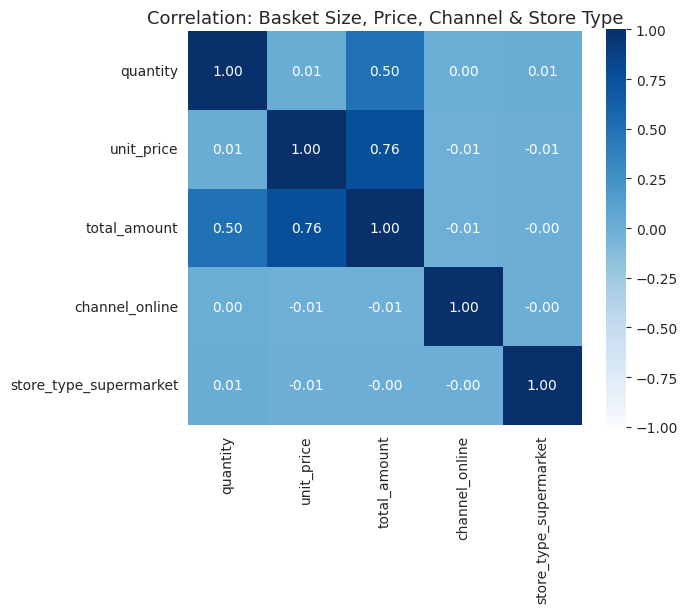

In [35]:
correlation_input = df[['quantity', 'unit_price', 'total_amount']].copy()
correlation_input['channel_online'] = (df['channel'] == 'Online').astype(int)
correlation_input['store_type_supermarket'] = (df['store_type'] == 'Supermarket').astype(int)

correlation_matrix = correlation_input.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='Blues', vmin=-1, vmax=1, square=True)
plt.title('Correlation: Basket Size, Price, Channel & Store Type')
plt.tight_layout()
plt.show()

**Findings**
- Average basket size is nearly identical across Online vs Offline and Kirana vs Supermarket — no combination stands out.
- `quantity` shows negligible correlation with both `channel_online` and `store_type_supermarket`, confirming basket size is not driven by where or how the order is placed.
- `total_amount` correlates with `quantity` and `unit_price` as expected (it is derived from them), but not with channel or store type.

**Interpretation**
Channel and store type explain *where* revenue is generated, not *how much* customers buy per order — basket size is essentially a fixed customer behaviour that doesn't shift by format.

**Recommendation**
Don't expect channel-mix changes (e.g. pushing Online) to grow basket size — pair any channel investment with separate basket-building tactics (bundling, cross-sell) if larger orders are the goal.

## Three Key Business Observations

The following three observations are the most consequential findings in this analysis, each paired with its own supporting chart.

### Observation 1: Revenue Leadership Is Volume-Driven, Not Value-Driven

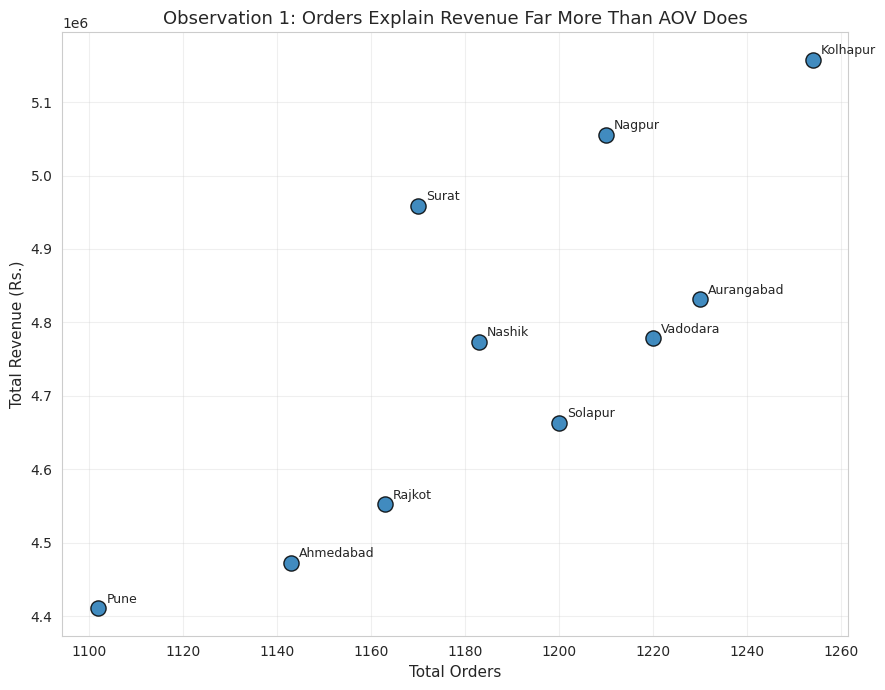

In [36]:
plt.figure(figsize=(9, 7))
plt.scatter(city_orders_aov_summary['total_orders'], city_orders_aov_summary['total_revenue'],
            s=120, color=COLOR_REVENUE, edgecolor='black', alpha=0.85)
for city, row in city_orders_aov_summary.iterrows():
    plt.annotate(city, (row['total_orders'], row['total_revenue']),
                 textcoords="offset points", xytext=(6, 4), fontsize=9)
plt.title('Observation 1: Orders Explain Revenue Far More Than AOV Does')
plt.xlabel('Total Orders')
plt.ylabel('Total Revenue (Rs.)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Cities line up almost linearly on orders-vs-revenue, while average order value stays flat across all of them — the strongest lever for city-level revenue growth is order frequency, not basket size.

### Observation 2: A Handful of Categories Combine High Revenue With High Return Risk

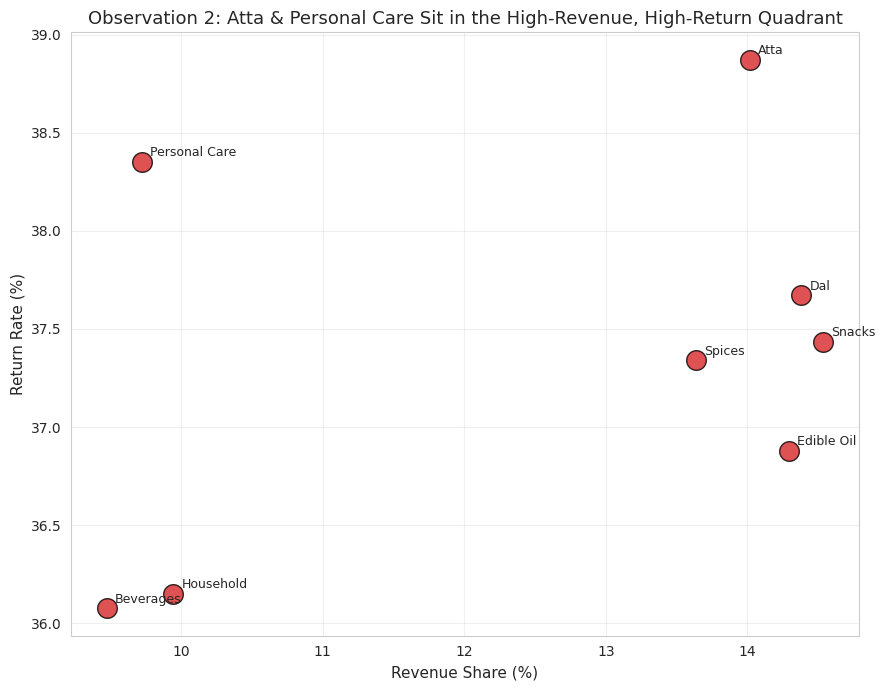

In [37]:
plt.figure(figsize=(9, 7))
plt.scatter(category_opportunity_matrix['revenue_share_pct'], category_opportunity_matrix['return_rate_pct'],
            s=200, color=COLOR_RETURNS, edgecolor='black', alpha=0.8)
for cat, row in category_opportunity_matrix.iterrows():
    plt.annotate(cat, (row['revenue_share_pct'], row['return_rate_pct']),
                 textcoords="offset points", xytext=(6, 4), fontsize=9)
plt.title('Observation 2: Atta & Personal Care Sit in the High-Revenue, High-Return Quadrant')
plt.xlabel('Revenue Share (%)')
plt.ylabel('Return Rate (%)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Atta and Personal Care are not the top revenue categories, but they carry the highest return rates of all 8 categories — making them the highest-value operational fix available.

### Observation 3: Rajkot's Top Revenue Product Is Its Biggest Risk Concentration

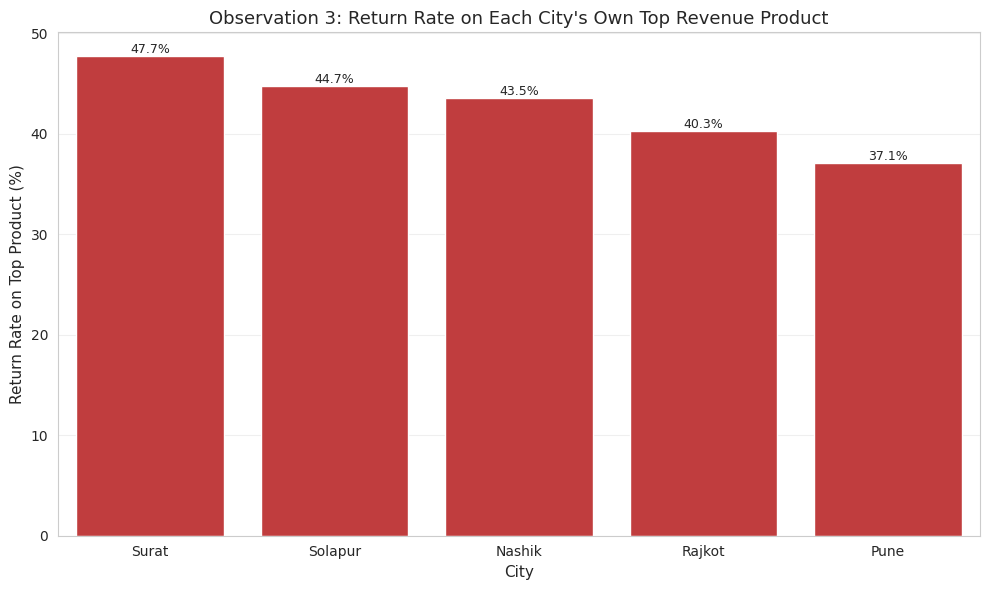

In [38]:
top5_risk_cities = city_top_product_summary.sort_values('return_rate_pct', ascending=False).head(5)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top5_risk_cities, x='city', y='return_rate_pct', color=COLOR_RETURNS)
plt.title('Observation 3: Return Rate on Each City\'s Own Top Revenue Product')
plt.xlabel('City')
plt.ylabel('Return Rate on Top Product (%)')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(top5_risk_cities['return_rate_pct']):
    ax.text(i, v, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Rajkot's top revenue product, NexaGold Wheat Atta 5kg, has a return rate well above every other city's top product — a single-product, single-city issue large enough to merit its own audit.

## Recommendations

1. **Rajkot should be prioritized for operational investigation** because NexaGold Wheat Atta 5kg contributes 9.2% of the city's revenue while experiencing a 40.3% return rate. The investigation should focus on identifying whether returns are driven by product quality, delivery damage, incorrect order fulfillment, or supplier-specific issues.

2. **NexaRetail should adopt city-specific inventory planning and promotional campaigns** instead of a uniform nationwide strategy. Product preferences vary considerably across cities, indicating that localized merchandising could improve both inventory efficiency and marketing effectiveness.

3. **Validate seasonal channel strategy before scaling marketing spend.** The alternating leadership between Online and Offline channels across the year suggests seasonal shifts in customer purchasing behaviour. Future campaigns should be designed only after confirming these shifts are accompanied by higher order volumes.

4. **Focus revenue growth on transaction frequency, not basket size.** High-performing cities achieve stronger revenue through a greater number of orders rather than significantly higher average order values.

5. **Investigate regional operational issues.** Some cities show disproportionately higher return rates for their top products. Focus quality checks, supplier audits, and logistics reviews there first.

## Executive Summary

### Key Findings

1. Revenue is well diversified across categories.
2. Revenue growth is driven primarily by higher order volume.
3. Product preferences differ considerably by city.
4. Rajkot, Surat and Nashik require operational attention.
5. Returns are distributed across multiple operational issues.

### Strategic Recommendations

| Priority | Recommendation | Business Impact | Confidence |
|----------|-----------------|------------------|------------|
| High | Audit Rajkot's NexaGold Wheat Atta 5kg (9.2% city revenue, 40.3% return rate) | Reduces losses on the single highest revenue-risk product identified | High |
| High | Investigate quality, delivery and fulfillment processes driving the ~37% overall return rate | Directly improves margin across the entire business | High |
| Medium | Adopt city-specific inventory and promotion planning | Improves inventory efficiency and marketing ROI | Medium |
| Medium | Shift growth strategy toward increasing transaction frequency over basket size | Aligns investment with the actual driver of city-level revenue leadership | Medium |
| Low | Validate the seasonal Online/Offline channel shift before scaling campaigns | Prevents misallocated marketing spend | Medium |

## Final Conclusion

### Business Health

- 🟢 Revenue diversified
- 🟡 Returns moderately high
- 🟢 Regional opportunities identified
- 🟡 Order value stable
- 🔴 Operational focus required in Rajkot, Surat and Nashik

### Business Priorities

1. Reduce returns in high-revenue products.
2. Localize inventory.
3. Increase transaction frequency.
4. Improve regional logistics.
5. Validate seasonal channel strategy.